In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lucalullo/european-employment-unemployment-rates-2015-2024/disoccupazione.csv
/kaggle/input/datasets/lucalullo/european-employment-unemployment-rates-2015-2024/occupazione.csv


## LOAD DATA

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("Libraries loaded")



emp = pd.read_csv("/kaggle/input/datasets/lucalullo/european-employment-unemployment-rates-2015-2024/occupazione.csv")
unemp = pd.read_csv("/kaggle/input/datasets/lucalullo/european-employment-unemployment-rates-2015-2024/disoccupazione.csv")

print("Employment shape:", emp.shape)
print("Unemployment shape:", unemp.shape)



Libraries loaded
Employment shape: (420, 13)
Unemployment shape: (2450, 13)


## CLEAN DATA

In [3]:

years = [c for c in emp.columns if c.isdigit()]

emp[years] = emp[years].apply(pd.to_numeric, errors="coerce")
unemp[years] = unemp[years].apply(pd.to_numeric, errors="coerce")

emp[years] = emp[years].fillna(emp[years].mean())
unemp[years] = unemp[years].fillna(unemp[years].mean())

## Rename columns
emp["TYPE"] = "Employment"
unemp["TYPE"] = "Unemployment"

## Combine datasets
df = pd.concat([emp, unemp], ignore_index=True)

print("Combined dataset:", df.shape)

Combined dataset: (2870, 14)


## ENCODE CATEGORIES

In [4]:
le_sex = LabelEncoder()
le_age = LabelEncoder()
le_iso = LabelEncoder()
le_type = LabelEncoder()

df["SEX"] = le_sex.fit_transform(df["SEX"])
df["AGE"] = le_age.fit_transform(df["AGE"])
df["ISO"] = le_iso.fit_transform(df["ISO"])
df["TYPE"] = le_type.fit_transform(df["TYPE"])

## LONG FORMAT

In [5]:



df_long = df.melt(
    id_vars=["SEX","AGE","ISO","TYPE"],
    value_vars=years,
    var_name="Year",
    value_name="Rate"
)

df_long["Year"] = df_long["Year"].astype(int)

print("Long dataset:", df_long.shape)

Long dataset: (28700, 6)


## VISUALIZATIONS 

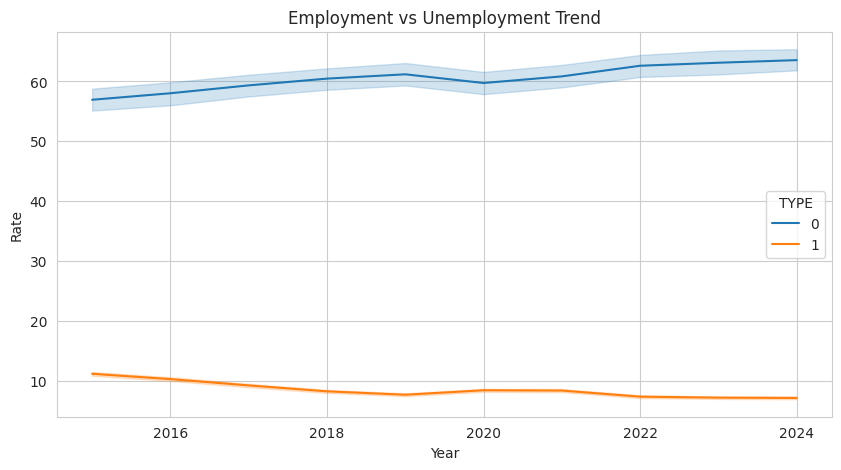

In [6]:
# 1 Trend
plt.figure(figsize=(10,5))
sns.lineplot(data=df_long, x="Year", y="Rate", hue="TYPE")
plt.title("Employment vs Unemployment Trend")
plt.show()

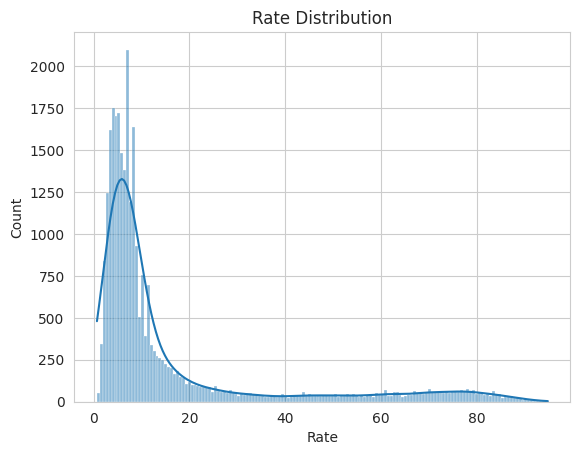

In [7]:
# 2 Distribution
sns.histplot(df_long["Rate"], kde=True)
plt.title("Rate Distribution")
plt.show()

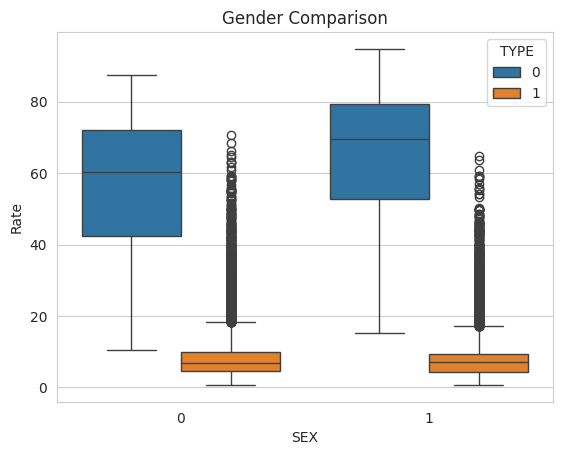

In [8]:
# 3 Gender Boxplot
sns.boxplot(x="SEX", y="Rate", hue="TYPE", data=df_long)
plt.title("Gender Comparison")
plt.show()

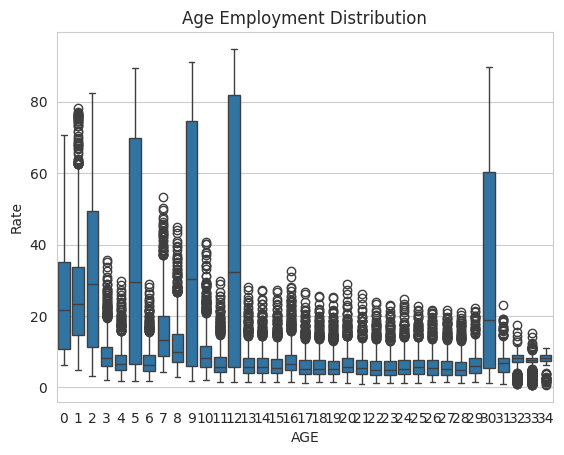

In [9]:
# 4 Age Group
sns.boxplot(x="AGE", y="Rate", data=df_long)
plt.title("Age Employment Distribution")
plt.show()

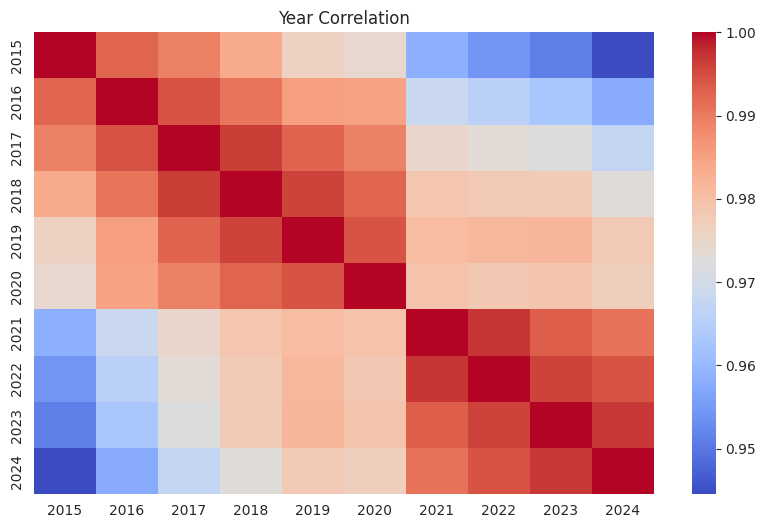

In [10]:
# 5 Correlation
plt.figure(figsize=(10,6))
sns.heatmap(df[years].corr(), cmap="coolwarm")
plt.title("Year Correlation")
plt.show()

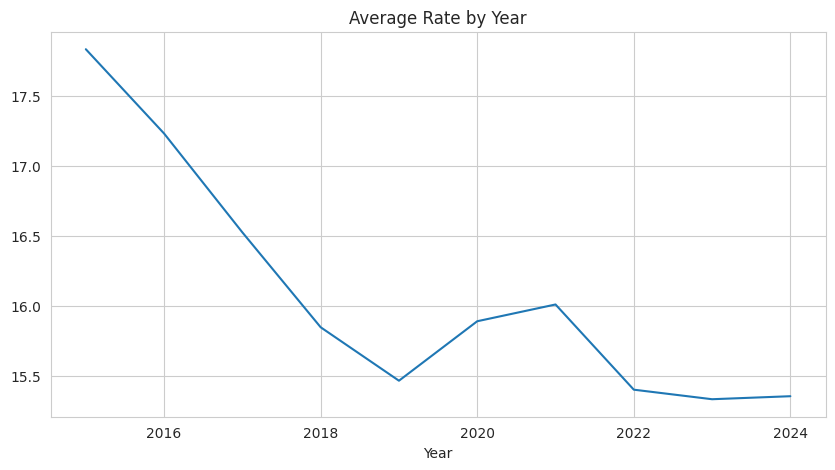

In [11]:
# 6 Mean per Year
df_long.groupby("Year")["Rate"].mean().plot(figsize=(10,5))
plt.title("Average Rate by Year")
plt.show()

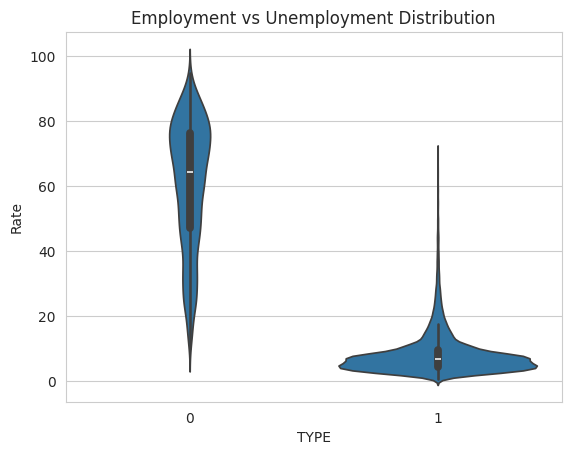

In [12]:
# 7 Violin
sns.violinplot(x="TYPE", y="Rate", data=df_long)
plt.title("Employment vs Unemployment Distribution")
plt.show()

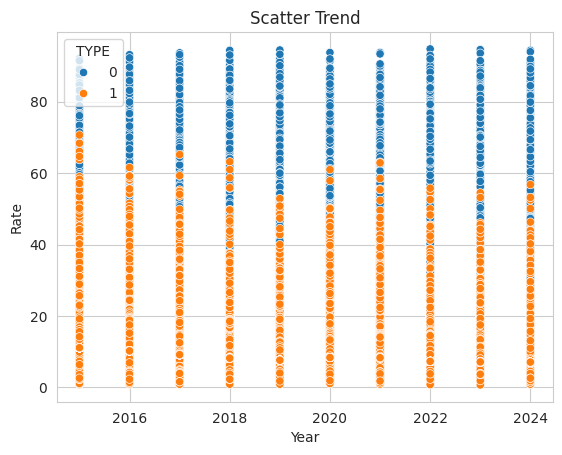

In [13]:
# 8 Scatter
sns.scatterplot(data=df_long, x="Year", y="Rate", hue="TYPE")
plt.title("Scatter Trend")
plt.show()

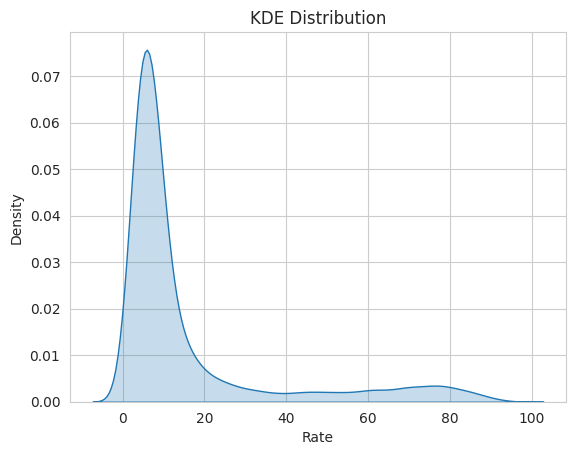

In [14]:
# 9 KDE
sns.kdeplot(df_long["Rate"], fill=True)
plt.title("KDE Distribution")
plt.show()


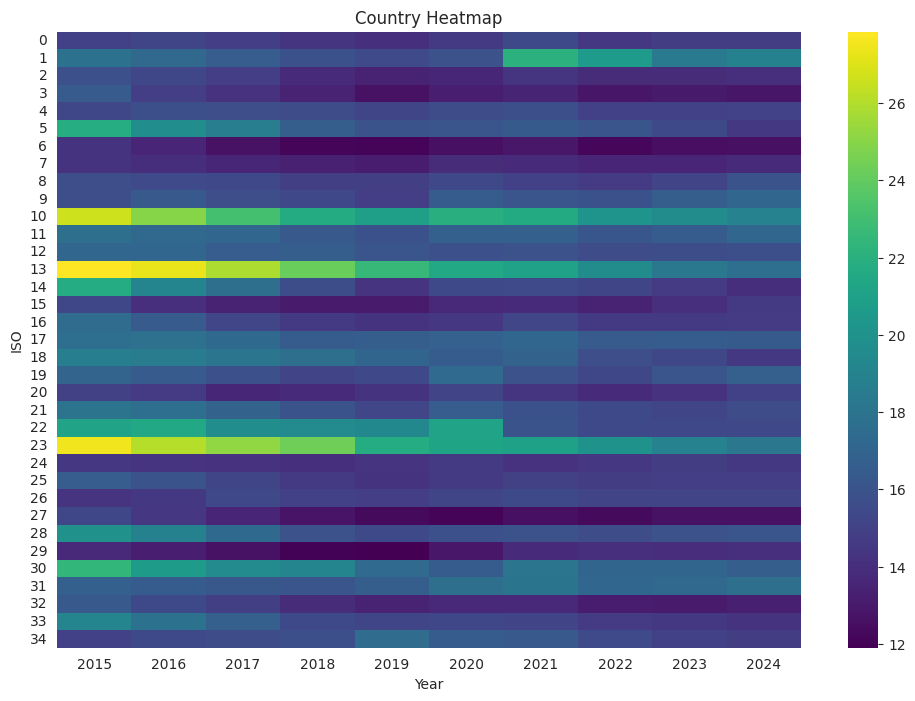

In [15]:
# 10 Heatmap
pivot = df_long.pivot_table(values="Rate", index="ISO", columns="Year")

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap="viridis")
plt.title("Country Heatmap")
plt.show()


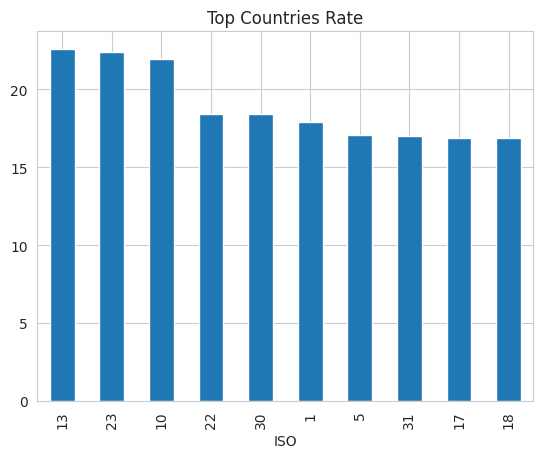

In [16]:
# 11 Top Countries
df_long.groupby("ISO")["Rate"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Countries Rate")
plt.show()


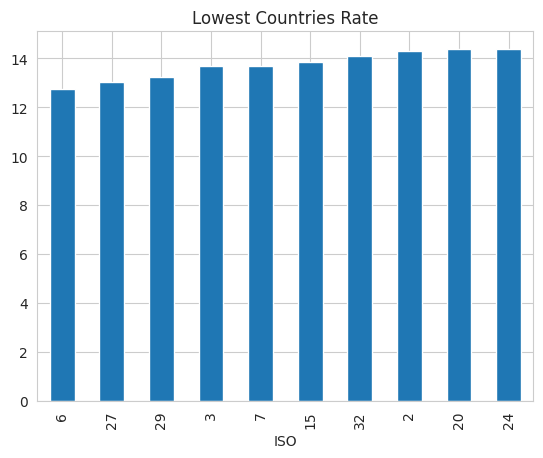

In [17]:
# 12 Lowest Countries
df_long.groupby("ISO")["Rate"].mean().sort_values().head(10).plot(kind="bar")
plt.title("Lowest Countries Rate")
plt.show()


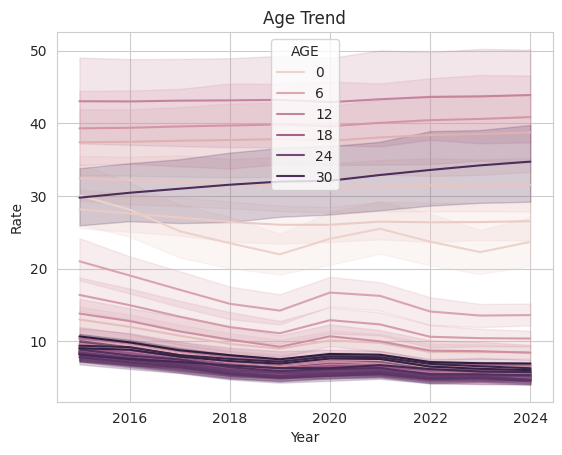

In [18]:
# 13 Age Trend
sns.lineplot(data=df_long, x="Year", y="Rate", hue="AGE")
plt.title("Age Trend")
plt.show()


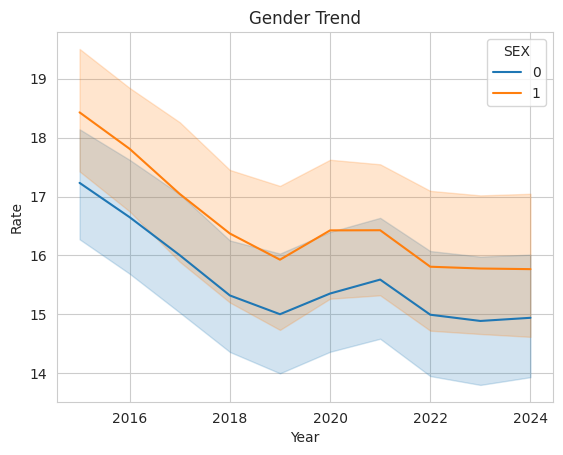

In [19]:
# 14 Gender Trend
sns.lineplot(data=df_long, x="Year", y="Rate", hue="SEX")
plt.title("Gender Trend")
plt.show()

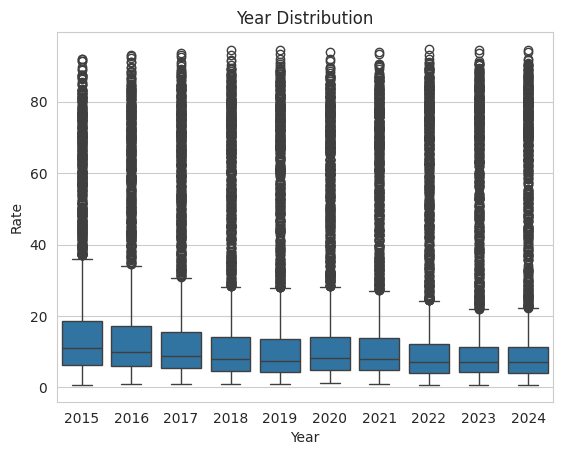

In [20]:
# 15 Box Year
sns.boxplot(x="Year", y="Rate", data=df_long)
plt.title("Year Distribution")
plt.show()


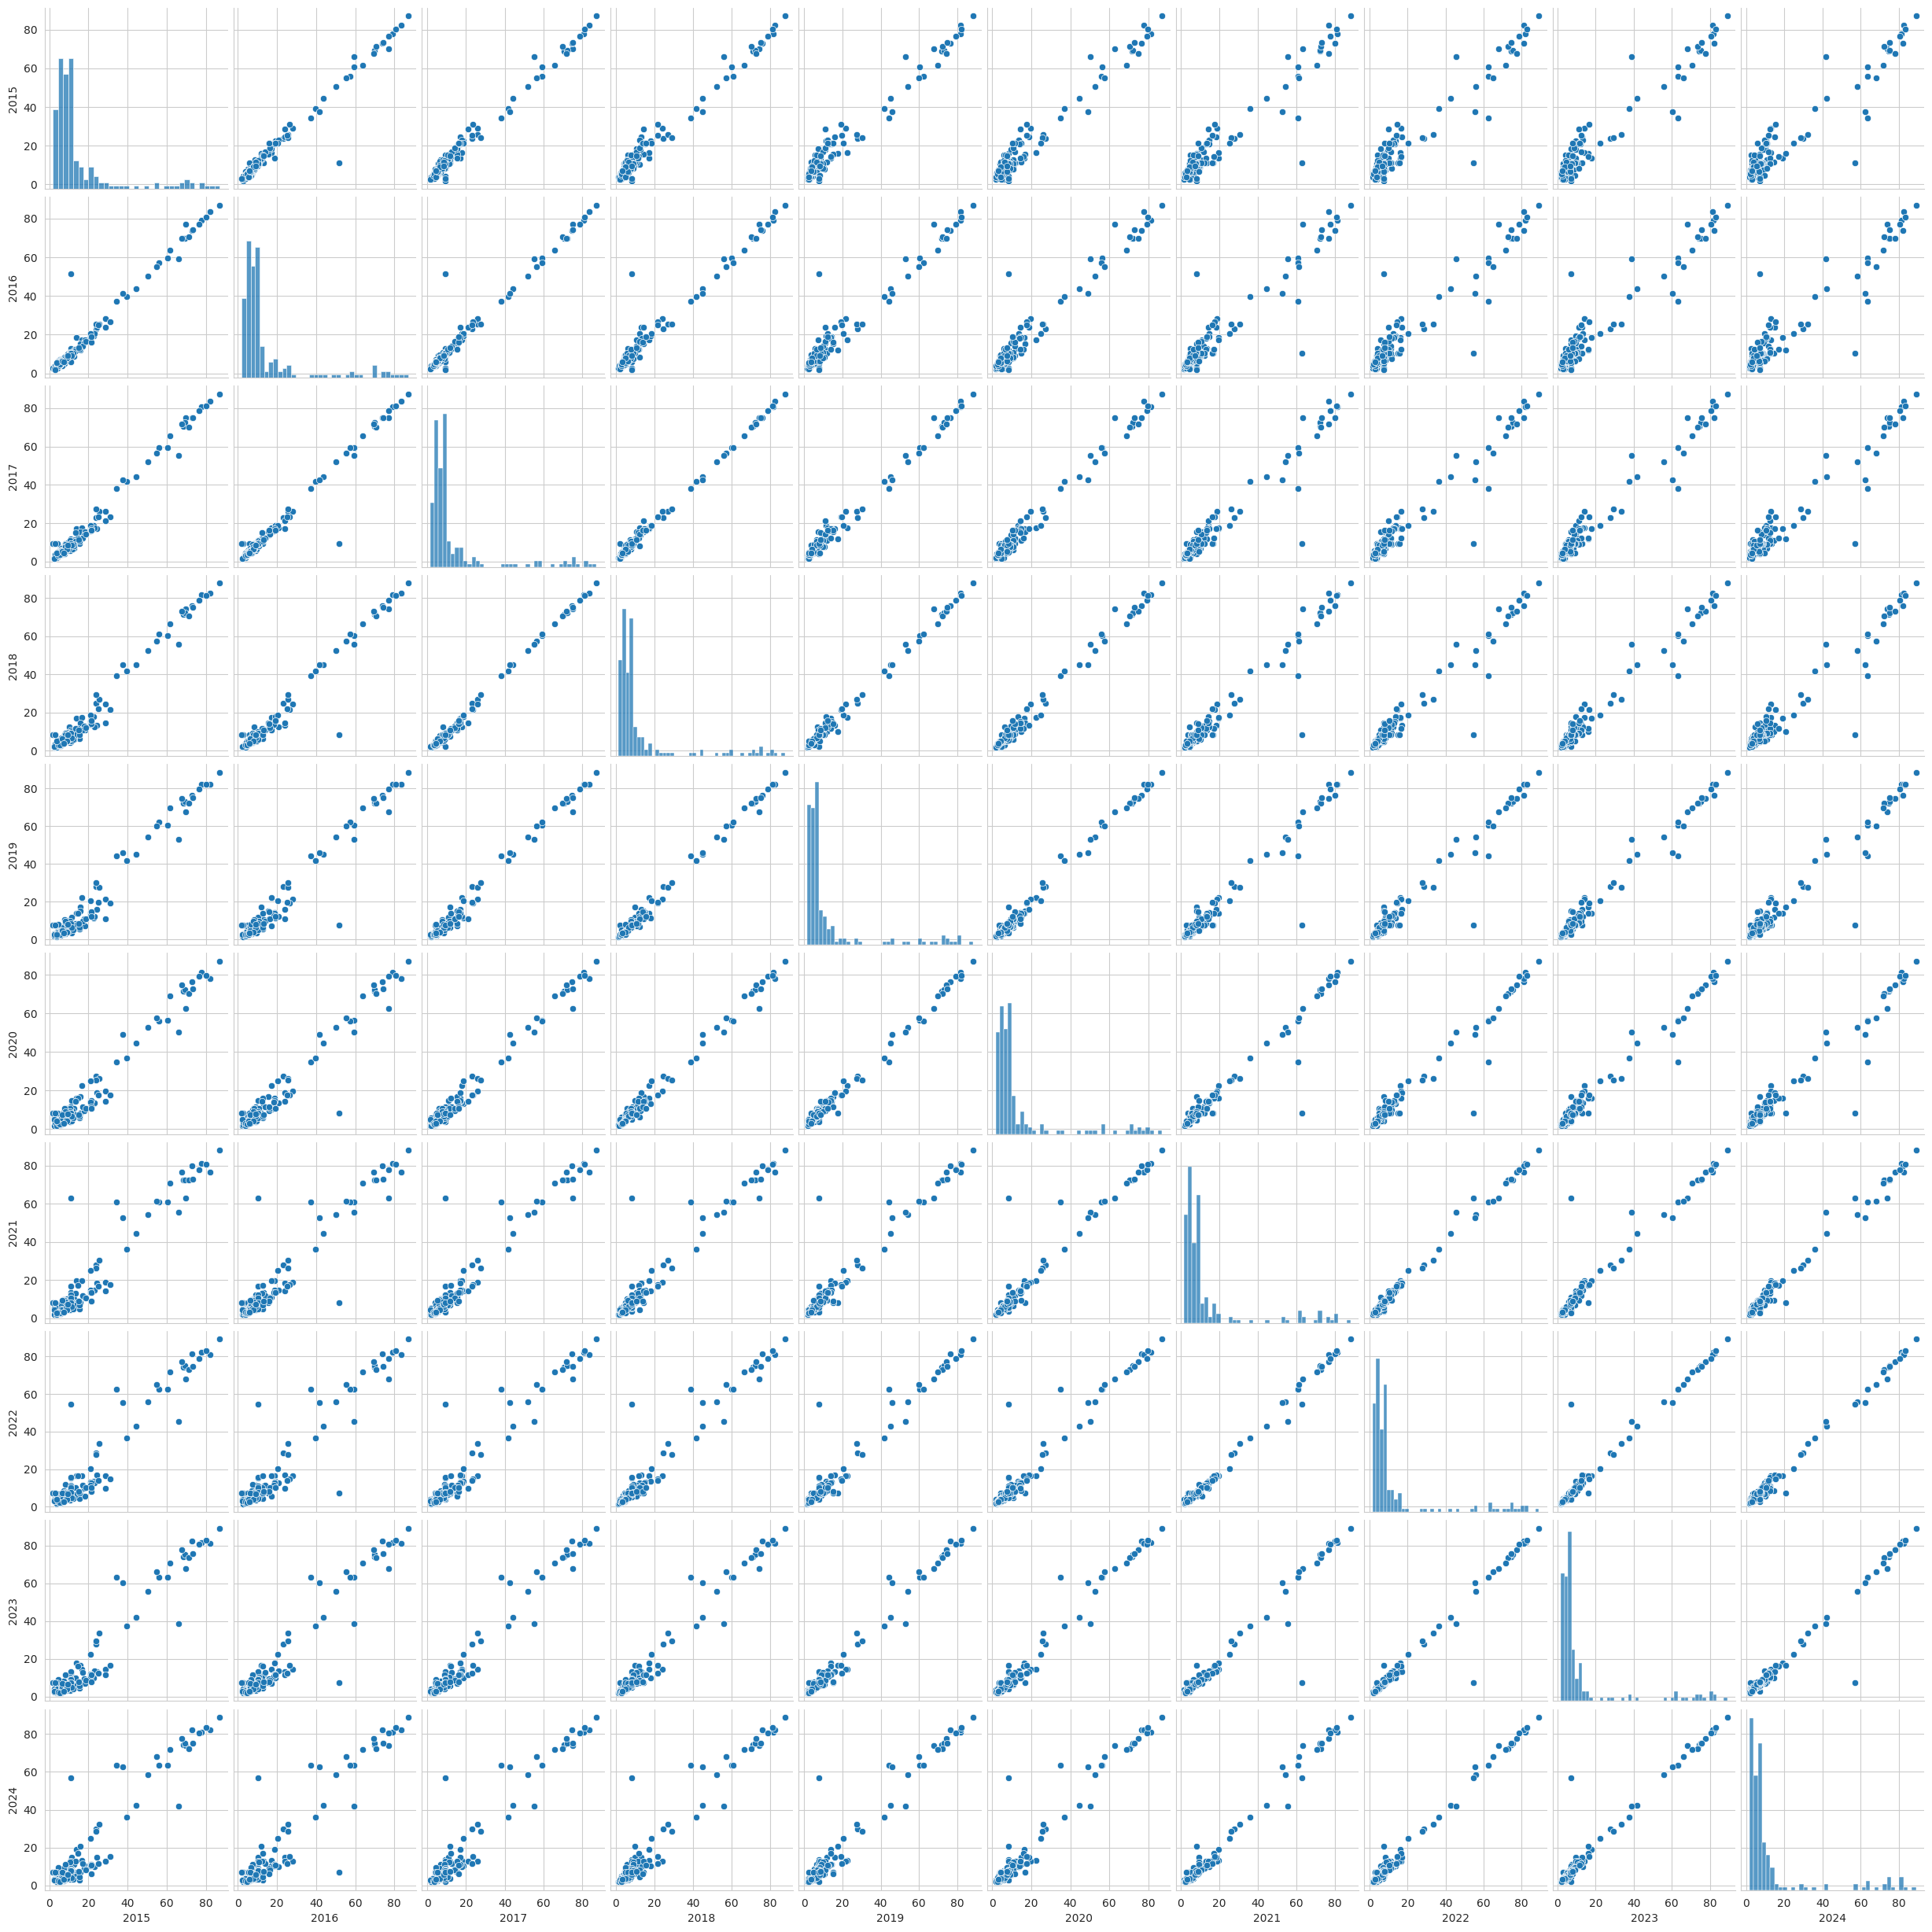

In [21]:
# 16 Pairplot
sns.pairplot(df[years].sample(200))
plt.show()

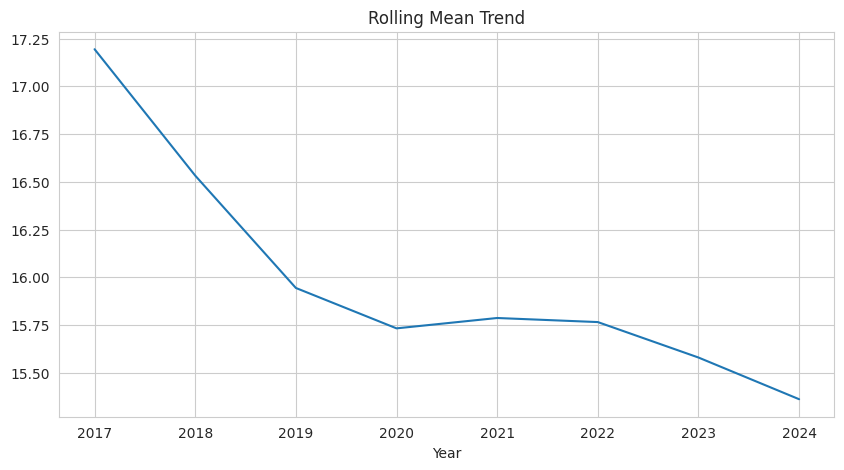

In [22]:
# 17 Rolling Mean
df_long.groupby("Year")["Rate"].mean().rolling(3).mean().plot(figsize=(10,5))
plt.title("Rolling Mean Trend")
plt.show()

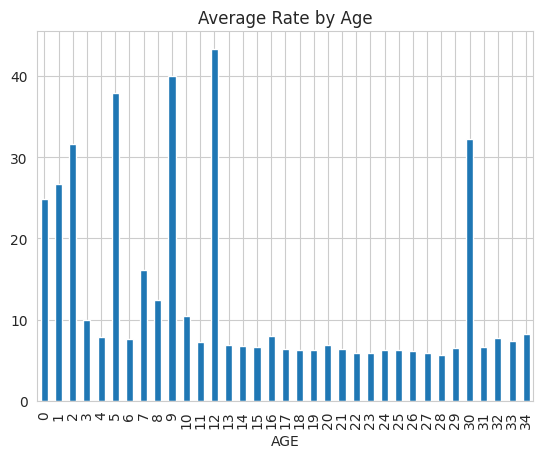

In [23]:
# 18 Age Bar
df_long.groupby("AGE")["Rate"].mean().plot(kind="bar")
plt.title("Average Rate by Age")
plt.show()


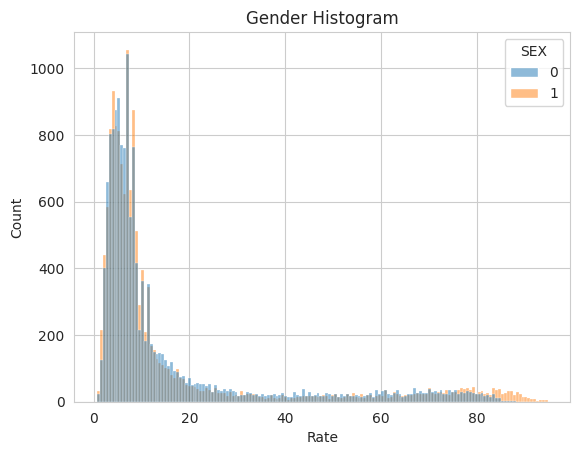

In [24]:
# 19 Histogram Gender
sns.histplot(data=df_long, x="Rate", hue="SEX")
plt.title("Gender Histogram")
plt.show()

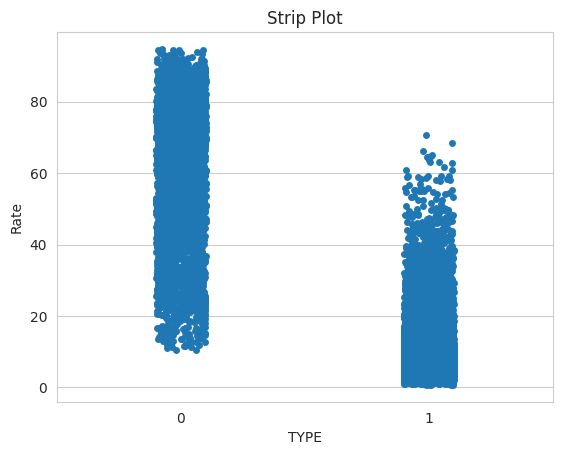

In [25]:
# 20 Strip Plot
sns.stripplot(x="TYPE", y="Rate", data=df_long)
plt.title("Strip Plot")
plt.show()

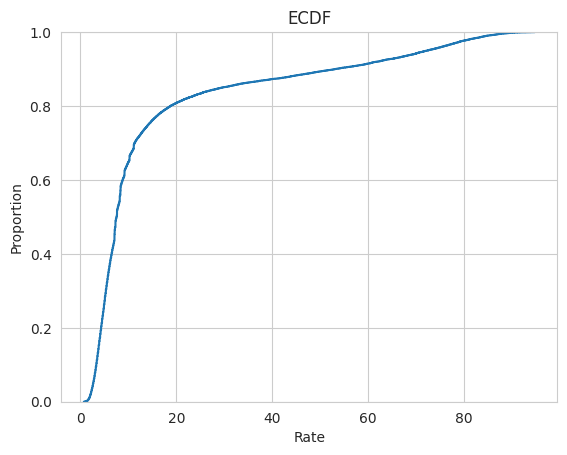

In [26]:
# 21 ECDF
sns.ecdfplot(df_long["Rate"])
plt.title("ECDF")
plt.show()

# MACHINE LEARNING (XGBoost)

RMSE: 1.621513691954397
R2: 0.9945326378223155


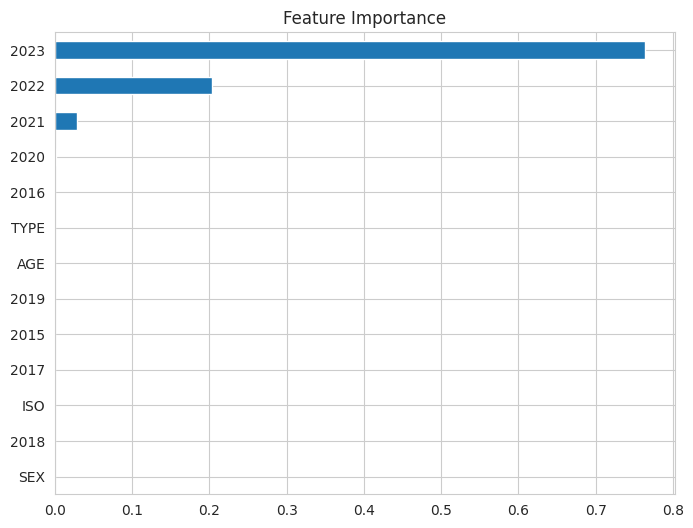

In [27]:


X = df[["SEX","AGE","ISO","TYPE"] + years[:-1]]
y = df[years[-1]]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test,pred))
r2 = r2_score(y_test,pred)

print("RMSE:", rmse)
print("R2:", r2)

# Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()


## PCA + COUNTRY CLUSTERING

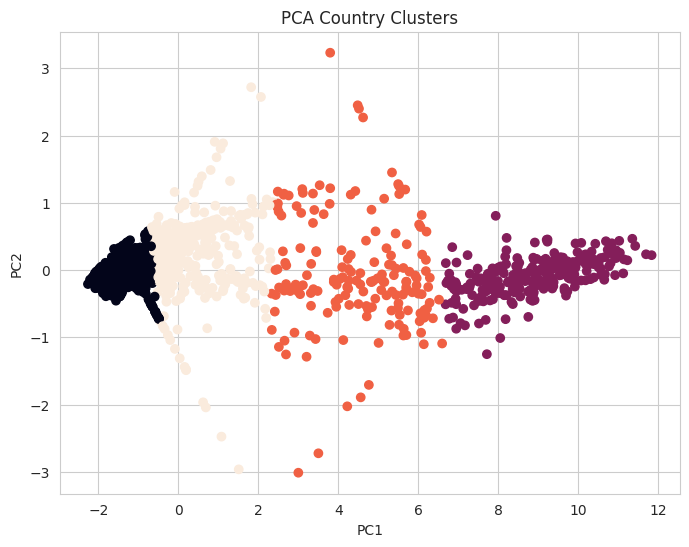

Explained Variance: [0.98193938 0.01227573]
Notebook finished successfully


In [28]:

scaler = StandardScaler()
scaled = scaler.fit_transform(df[years])

pca = PCA(n_components=2)
components = pca.fit_transform(scaled)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(components)

plt.figure(figsize=(8,6))
plt.scatter(components[:,0], components[:,1], c=clusters)
plt.title("PCA Country Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained Variance:", pca.explained_variance_ratio_)

print("Notebook finished successfully")